In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from urllib.parse import urlencode
from urllib.request import urlopen, Request
from pathlib import Path
import re
import urllib
import io

# Build network based on nodes and edges from dataset
(Do not run this section)

Here, we'll get all the nodes and edges defined from the dataset.

In [ ]:
nodes_df = pd.read_csv('Nodes.csv')
edges_df = pd.read_csv('Edges.csv', delimiter=';')

In [ ]:
network = nx.DiGraph()

# Feature to include from dataset
features = ['Name', 'NameURL', 'Link', 'birthcity', 'countryName', 'continentName', 'birthyear', 'deathyear', 'gender', 'occupation', 'industry']

In [ ]:
# Load nodes
for index, row in nodes_df.iterrows():
    network.add_node(row['Id'], **row[features].to_dict())

# Handling weird numberings
number_formatted_nodes = {
    "1,00E+03": "1000",
    "2,00E+03": "2000",
    "3,00E+03": "3000",
    "4,00E+03": "4000",
    "5,00E+03": "5000",
    "6,00E+03": "6000",
    "7,00E+03": "7000",
    "8,00E+03": "8000",
    "9,00E+03": "9000",
    "1,00E+04": "10000",
    "1,10E+04": "11000"
}

# Load edges
for index, row in edges_df.iterrows():
    try:
        source_id = row['Source']
        target_id = row['Target']
        if row['Source'] in number_formatted_nodes:
            source_id = number_formatted_nodes[row['Source']]
        if row['Target'] in number_formatted_nodes:
            target_id = number_formatted_nodes[row['Target']]
        network.add_edge(int(source_id), int(target_id))
    except Exception as e:
        print(f"Error adding edge from {row['Source']} to {row['Target']}: {e}")

We will fetch all Wikipedia pages of the nodes in our network.

In [ ]:
def get_wikitext(title):
    baseurl = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "format": "json"
    }
    query = f"{baseurl}?{urlencode(params)}"
    wikiurl = Request(query, headers={'User-Agent': 'Mozilla/5.0'})
    wikiresponse = urlopen(wikiurl)
    wikidata = wikiresponse.read()
    wikitext = json.loads(wikidata.decode("utf-8"))
    pageId = str(list(wikitext["query"]["pages"].keys())[0])
    page_text = wikitext["query"]["pages"][pageId]['revisions'][0]['slots']['main']['*']
    return page_text

In [ ]:
progress = 0
milestone = 10 # percent
total = network.number_of_nodes()
for node in network.nodes(data=True):
    nameURL = node[1]['NameURL']
    try:
        wikitext = get_wikitext(nameURL)
    except Exception as e:
        print(f"Error fetching wikitext for {nameURL}: {e}")
        continue
    with open(f'wikipages/{nameURL}.txt', 'w+', encoding='utf-8') as f:
        f.write(wikitext)
    progress += 1
    if (progress / total) * 100 >= milestone:
        print(f"Progress: {progress}/{total} ({(progress / total) * 100:.2f}%)")
        milestone += 10

Since our dataset was created on 2018, some Wikipedia page URLs hae been change since. Therefore, we check manually one by one to see the new URL and fetched them.

In [ ]:
# Check whether all pages are fetched
for node in network.nodes(data=True):
    nameURL = node[1]['NameURL']
    file_path = Path(f"wikipages/{nameURL}.txt")
    
    if not file_path.exists():
        print(f"\n❌ Failure: '{file_path}' was NOT found.")

In [ ]:
old_to_new_nameURL = {
    "Valdemar_IV_Atterdag_of_Denmark": "Valdemar_IV_of_Denmark",
    "Nicolas_de_Caritat,_marquis_de_Condorcet": "Marquis_de_Condorcet",
    "Donatien_Alphonse_François_de_Sade,_Marquis_de_Sade": "Marquis_de_Sade",
    "Geoffrey_V_Plantagenet,_Count_of_Anjou": "Geoffrey_Plantagenet,_Count_of_Anjou",
    "Charles_the_Bald,_Holy_Roman_Emperor": "Charles_the_Bald",
    "Clemens_Maria_Wenzeslaus_von_Brentano" : "Clemens_Brentano",
    "Dimitris_Kraniotris": "Dimitris_P._Kraniotis",
    "Edgar_the_Peaceful_of_England": "Edgar,_King_of_England",
    "Arnulf_of_Carinthia,_Holy_Roman_Emperor": "Arnulf_of_Carinthia"
}

for nameURL, newNameURL in old_to_new_nameURL.items():
    node_id = next((n for n, attr in network.nodes(data=True) if attr['NameURL'] == nameURL), None)
    network.nodes[node_id]['redirectNameURL'] = newNameURL
    try:
        wikitext = get_wikitext(old_to_new_nameURL[nameURL])
        with open(f'wikipages/{newNameURL}.txt', 'w+', encoding='utf-8') as f:
            f.write(wikitext)
    except Exception as e:
        print(f"Error fetching wikitext for {nameURL}: {e}")
        continue

Handle duplicated nodes in nodes_df based on 'NameURL' column

* Remove the first one for most because it doesn't have any edges pointing to it

* "James_Connolly" is a special case because there is the UK one and US one. A bit problematic so we will remove both

* "Matthew_Perry" is another special case, because the second node is the correct one

In [ ]:
duplicated_index = nodes_df.index[nodes_df.duplicated(subset=['NameURL'])]
nodes_df.loc[duplicated_index]

In [ ]:
remove_duplicate_node_id = [2024, 4987, 7669, 7921, 9900, 7888]

# Remove both James Connolly
james_id = [7656, 9880]

for node_id in remove_duplicate_node_id:
    assert len(edges_df[edges_df['Source'] == str(node_id)]) == 0 or len(edges_df[edges_df['Target'] == str(node_id)]) == 0
network.remove_nodes_from(remove_duplicate_node_id+james_id)

In [ ]:
# Check if there are any duplicates left
nodes_nameURL_list = []
for node in network.nodes(data=True):
    title = node[1]['NameURL']
    nodes_nameURL_list.append(title)
assert len(nodes_nameURL_list) == len(set(nodes_nameURL_list)), "There are still duplicate NameURL entries!"

Check any pages with #REDIRECT, check their first redirect link, and fetch them from Wikipedia API.

In [ ]:
regex = r"#REDIRECT\s*\[\[(.*?)\]\]"


In [ ]:
for node in list(network.nodes(data=True)):
    nameURL = node[1]['NameURL']
    file_path = Path(f"wikipages/{nameURL}.txt")
    if not file_path.exists():
        continue
    with open(file_path, 'r', encoding='utf-8') as f:
        wikitext = f.read()
        match = re.search(regex, wikitext, re.IGNORECASE)
        if match:
            redirect_title = match.group(1)
            network.nodes[node[0]]['redirectNameURL'] = redirect_title
            try:
                wikitext = get_wikitext(redirect_title)
            except Exception as e:
                print(f"Error fetching wikitext for {nameURL}: {e}")
                continue
            with open(f'wikipages/{nameURL}.txt', 'w', encoding='utf-8') as f:
                f.write(wikitext)

In [ ]:
# Check is all redirects are resolved
for node in network.nodes(data=True):
    nameURL = node[1]['NameURL']
    file_path = Path(f"wikipages/{nameURL}.txt")
    if not file_path.exists():
        continue
    with open(file_path, 'r', encoding='utf-8') as f:
        wikitext = f.read()
        match = re.search(regex, wikitext, re.IGNORECASE)
        assert not match, f"Redirect still found in {nameURL}"

In [ ]:
# Add wikicontent as a node attribute
for node in network.nodes(data=True):
    nameURL = node[1]['NameURL']
    file_path = Path(f"wikipages/{nameURL}.txt")
    if not file_path.exists():
        nameURL = node[1].get('redirectNameURL', None)
        if nameURL is None:
            print(f"\n❌ Failure: '{file_path}' was NOT found as an attribute.")
            continue
        file_path = Path(f"wikipages/{nameURL}.txt")
        if not file_path.exists():
            print(f"\n❌ Failure: '{file_path}' was NOT found.")
            continue
    with open(file_path, 'r', encoding='utf-8') as f:
        wikitext = f.read()
        network.nodes[node[0]]['wikicontent'] = wikitext

Handle case like Aaron Johnson or Fabio where there are multiple people with the same name but different Wikipedia pages.This problem is caused because these pages has disambiguation tag on them meaning that the name can refer to someone else or something else. So we need to find all nodes with disambiguation tags on their page and remoe them from the network. 

In [ ]:
directory_path = Path("wikipages")
files_found_path = list(directory_path.glob("*.txt"))
output_path = Path("wikipages_less300.txt")
ambiguation_list_by_word = []
for file_path in files_found_path:
    try:
        content = file_path.read_text(encoding='utf-8', errors='replace')
        word_count = len(content.split())
        if word_count < 300:
            ambiguation_list_by_word.append(file_path)
            with output_path.open("a", encoding="utf-8") as output_file:
                output_file.write(f"{content}\n{"+"*300}\n{"+"*300}\n")
            print(f"❌ Warning: '{file_path}' has only {word_count} words.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        continue
print(f"\nTotal files with less than 300 words: {len(ambiguation_list_by_word)}")

In [ ]:
disambiguation_regex = r"\{\{\s*(?:[^|}]*disambiguation|hndis|given name|surname|disambig|hndisambig|hndab)(?:\|.*?)?\}\}"

In [ ]:
directory_path = Path("wikipages")
files_found_path = list(directory_path.glob("*.txt"))
output_path = Path("wikipages_disambiguatiion_template.txt")
ambiguation_list_by_template = []
for file_path in files_found_path:
    try:
        content = file_path.read_text(encoding='utf-8', errors='replace')
        word_count = len(content.split())
        if re.search(disambiguation_regex, content, re.IGNORECASE):
            ambiguation_list_by_template.append(file_path)
            with output_path.open("a", encoding="utf-8") as output_file:
                output_file.write(f"{content}\n{"+"*300}\n{"+"*300}\n")
            print(f"❌ Warning: '{file_path}' contains a disambiguation template. Word count: {word_count}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        continue
print(f"\nTotal files with disambiguation templates: {len(ambiguation_list_by_template)}")

In [ ]:
# this is just for testing
diff = set(ambiguation_list_by_word) - set(ambiguation_list_by_template)
print(f"\nFiles with less than 300 words but no disambiguation template: {len(diff)}")
for file in diff:
    print(f" - {file}")

If you check, these pages are correct but just short

In [ ]:
removed_nodes = []
nodes = list(network.nodes(data=True))
for node in nodes:
    node_id = node[0]
    content = network.nodes[node_id].get('wikicontent', '')
    word_count = len(content.split())
    if re.search(disambiguation_regex, content, re.IGNORECASE):
        print(f"Node ID {node_id} with NameURL {network.nodes[node_id]['NameURL']} word count {word_count} contains a disambiguation template.")
        removed_nodes.append((node_id, network.nodes[node_id]['NameURL']))
        network.remove_node(node_id)
print(f"\nTotal nodes removed due to disambiguation templates: {len(removed_nodes)}")

# Save network
(Do not run this section)

In [ ]:
nx.write_graphml(network, "celebrities_clean.graphml")

In [ ]:
network_without_content = network.copy()
for node in network_without_content.nodes(data=True):
    if 'wikicontent' in node[1]:
        del node[1]['wikicontent']

In [ ]:
nx.write_graphml(network_without_content, "celebrities_clean_without_content.graphml")

# Load network

In [2]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

undirected = network.to_undirected()

✓ Network loaded successfully!
  Nodes: 11286
  Edges: 125705


# Network Analysis

## Basic Network Statistics

First, let's examine the basic properties of our network.

In [3]:
# Basic network statistics
print("="*80)
print("BASIC NETWORK STATISTICS")
print("="*80)
print(f"Number of nodes: {network.number_of_nodes()}")
print(f"Number of edges: {network.number_of_edges()}")
print(f"Network density: {nx.density(network):.6f}")
print(f"Is directed: {nx.is_directed(network)}")

# Check if network is connected
if nx.is_directed(network):
    is_strongly_connected = nx.is_strongly_connected(network)
    is_weakly_connected = nx.is_weakly_connected(network)
    print(f"Is strongly connected: {is_strongly_connected}")
    print(f"Is weakly connected: {is_weakly_connected}")
    
    # Number of connected components
    num_strongly = nx.number_strongly_connected_components(network)
    num_weakly = nx.number_weakly_connected_components(network)
    print(f"Number of strongly connected components: {num_strongly}")
    print(f"Number of weakly connected components: {num_weakly}")
    
    # Size of largest component
    largest_scc = max(nx.strongly_connected_components(network), key=len)
    largest_wcc = max(nx.weakly_connected_components(network), key=len)
    print(f"Largest strongly connected component size: {len(largest_scc)} ({len(largest_scc)/network.number_of_nodes()*100:.2f}%)")
    print(f"Largest weakly connected component size: {len(largest_wcc)} ({len(largest_wcc)/network.number_of_nodes()*100:.2f}%)")
else:
    is_connected = nx.is_connected(network)
    print(f"Is connected: {is_connected}")
    num_components = nx.number_connected_components(network)
    print(f"Number of connected components: {num_components}")

BASIC NETWORK STATISTICS
Number of nodes: 11286
Number of edges: 125705
Network density: 0.000987
Is directed: True
Is strongly connected: False
Is weakly connected: False
Number of strongly connected components: 1599
Number of weakly connected components: 233
Largest strongly connected component size: 9563 (84.73%)
Largest weakly connected component size: 11023 (97.67%)
Number of strongly connected components: 1599
Number of weakly connected components: 233
Largest strongly connected component size: 9563 (84.73%)
Largest weakly connected component size: 11023 (97.67%)


## Degree Analysis

Analyzing the in-degree and out-degree distributions of the network.

In [4]:
# Calculate degrees
in_degrees = np.array(list(dict(network.in_degree()).values()))
out_degrees = np.array(list(dict(network.out_degree()).values()))
total_degrees = in_degrees + out_degrees

# Top nodes by degree
in_degree_dict = dict(network.in_degree())
out_degree_dict = dict(network.out_degree())

print("\n" + "="*80)
print("TOP 10 NODES BY IN-DEGREE")
print("="*80)
sorted_in = sorted(in_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
for i, (node, degree) in enumerate(sorted_in, 1):
    name = network.nodes[node].get('Name', 'Unknown')
    print(f"{i:2d}. {name:<40} - In-degree: {degree}")

print("\n" + "="*80)
print("TOP 10 NODES BY OUT-DEGREE")
print("="*80)
sorted_out = sorted(out_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
for i, (node, degree) in enumerate(sorted_out, 1):
    name = network.nodes[node].get('Name', 'Unknown')
    print(f"{i:2d}. {name:<40} - Out-degree: {degree}")


TOP 10 NODES BY IN-DEGREE
 1. Barack Obama                             - In-degree: 414
 2. Adolf Hitler                             - In-degree: 339
 3. William Shakespeare                      - In-degree: 314
 4. George Bush                              - In-degree: 286
 5. Joseph Stalin                            - In-degree: 232
 6. Ronald Reagan                            - In-degree: 209
 7. Bill Clinton                             - In-degree: 204
 8. Donald Trump                             - In-degree: 200
 9. Roger Ebert                              - In-degree: 194
10. John F. Kennedy                          - In-degree: 191

TOP 10 NODES BY OUT-DEGREE
 1. Meryl Streep                             - Out-degree: 105
 2. Martin Scorsese                          - Out-degree: 102
 3. David Beckham                            - Out-degree: 95
 4. Bob Dylan                                - Out-degree: 94
 5. Ennio Morricone                          - Out-degree: 92
 6. Friedrich

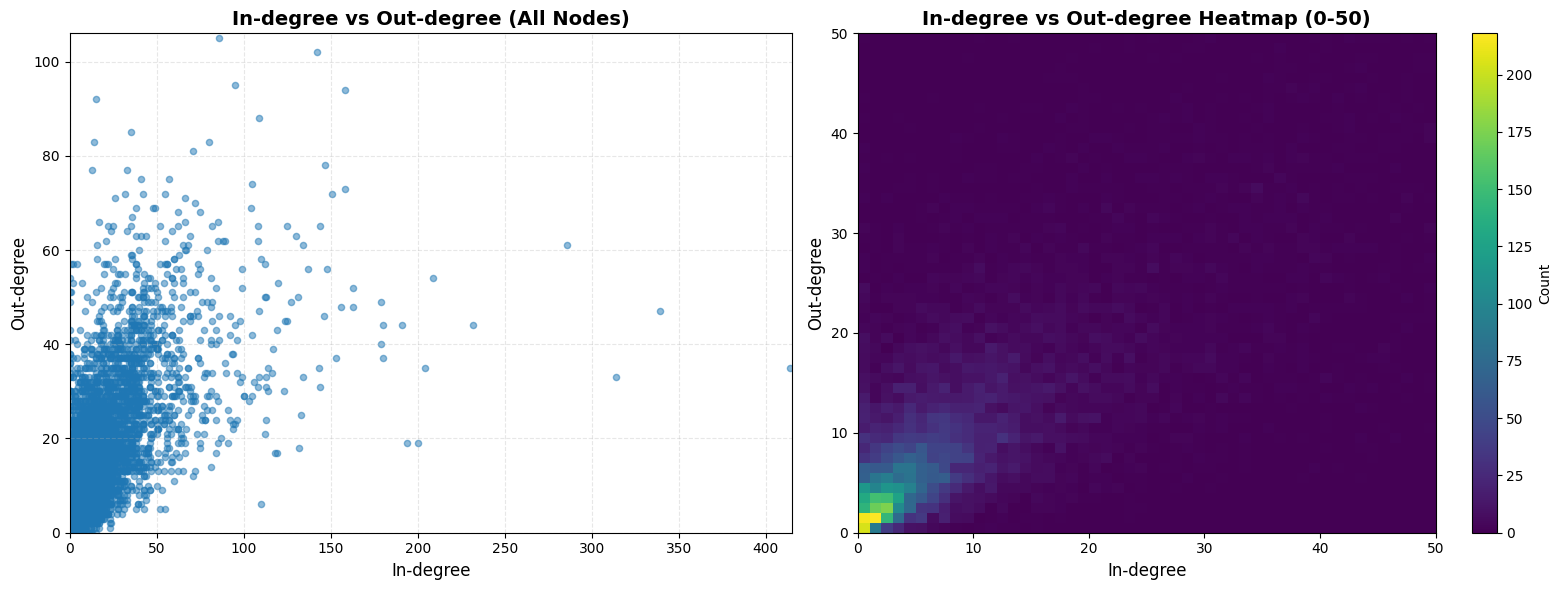

In [5]:
# Visualize In-degree vs Out-degree
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(in_degrees, out_degrees, alpha=0.5, s=20)
axes[0].set_title("In-degree vs Out-degree (All Nodes)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("In-degree", fontsize=12)
axes[0].set_ylabel("Out-degree", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].set_xlim(0, max(in_degrees)+1)
axes[0].set_ylim(0, max(out_degrees)+1)

# Heatmap for nodes with degree <= 50
mask = (in_degrees <= 50) & (out_degrees <= 50)
x = in_degrees[mask]
y = out_degrees[mask]

heatmap, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[0,50],[0,50]])
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = axes[1].imshow(
    heatmap.T,
    extent=extent,
    origin='lower',
    cmap='viridis',
    interpolation='nearest',
    aspect='auto'
)

axes[1].set_title("In-degree vs Out-degree Heatmap (0-50)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("In-degree", fontsize=12)
axes[1].set_ylabel("Out-degree", fontsize=12)
plt.colorbar(im, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

It is show that the relation between In and Out degree are somewhat linear.

## Degree Distribution

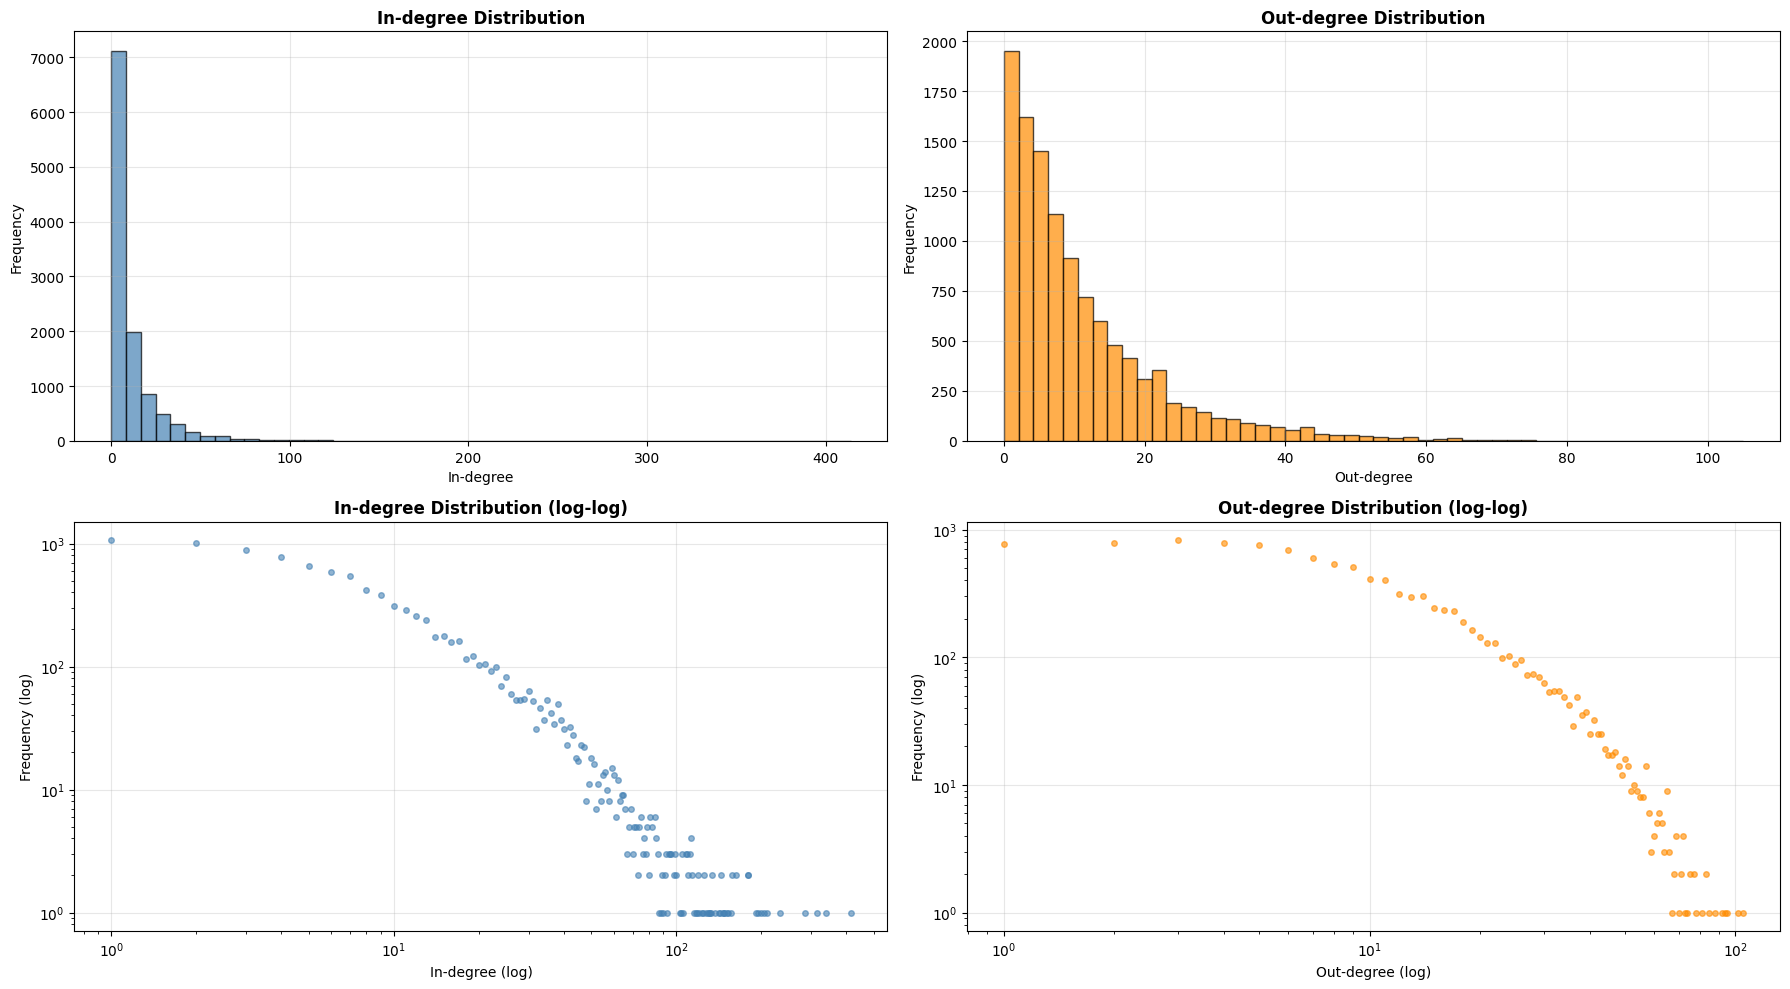

In [6]:
# Plot degree distributions
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# In-degree histogram
axes[0, 0].hist(in_degrees, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title("In-degree Distribution", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, alpha=0.3)

# Out-degree histogram
axes[0, 1].hist(out_degrees, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[0, 1].set_title("Out-degree Distribution", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Out-degree")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True, alpha=0.3)

# Log-log plots for power-law analysis
# In-degree
in_deg_counts = np.bincount(in_degrees)
in_deg_values = np.arange(len(in_deg_counts))
mask_in = (in_deg_counts > 0) & (in_deg_values > 0)
axes[1, 0].loglog(in_deg_values[mask_in], in_deg_counts[mask_in], 'o', markersize=4, alpha=0.6, color='steelblue')
axes[1, 0].set_title("In-degree Distribution (log-log)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("In-degree (log)")
axes[1, 0].set_ylabel("Frequency (log)")
axes[1, 0].grid(True, alpha=0.3)

# Out-degree
out_deg_counts = np.bincount(out_degrees)
out_deg_values = np.arange(len(out_deg_counts))
mask_out = (out_deg_counts > 0) & (out_deg_values > 0)
axes[1, 1].loglog(out_deg_values[mask_out], out_deg_counts[mask_out], 'o', markersize=4, alpha=0.6, color='darkorange')
axes[1, 1].set_title("Out-degree Distribution (log-log)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Out-degree (log)")
axes[1, 1].set_ylabel("Frequency (log)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

From the linear scale, it is shown that both degree distribution have high low degree nodes and only a few high degree outliers. From the log log scale, we can see clearer the tail on the high degree node. This observation means that the network follows a power law but we'll further back it up with more analysis.

## Assortativity

In [7]:
# Calculate assortativity coefficient
assortativity = nx.degree_assortativity_coefficient(network)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")

Degree Assortativity Coefficient: 0.0631


This shows a quite high assortativity meaning that the high degree nodes tend to connect with other high degree nodes

## Centrality Analysis

In [9]:
# Load centrality data from cache
import pickle

with open('centrality_cache.pkl', 'rb') as f:
    centrality_data = pickle.load(f)

print("Loaded centrality measures from cache:")
print(f"Available measures: {list(centrality_data.keys())}")
print()

# Extract centrality measures
betweenness = centrality_data.get('betweenness', {})
eigenvector = centrality_data.get('eigenvector', {})

# Display top 5 nodes for each centrality measure

print("\n" + "="*80)
print("Top 5 Nodes by Betweenness Centrality:")
print("="*80)
for node, score in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{network.nodes[node]['Name']}: {score:.6f}")

print("\n" + "="*80)
print("Top 5 Nodes by Eigenvector Centrality:")
print("="*80)
for node, score in sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{network.nodes[node]['Name']}: {score:.6f}")

Loaded centrality measures from cache:
Available measures: ['degree', 'betweenness', 'closeness', 'eigenvector', 'pagerank']


Top 5 Nodes by Betweenness Centrality:
Barack Obama: 0.042260
Adolf Hitler: 0.040600
William Shakespeare: 0.025570
George Bush: 0.023800
Pope John Paul II: 0.020291

Top 5 Nodes by Eigenvector Centrality:
Barack Obama: 0.159321
George Bush: 0.109099
Roger Ebert: 0.106388
Ronald Reagan: 0.101917
Martin Scorsese: 0.095358


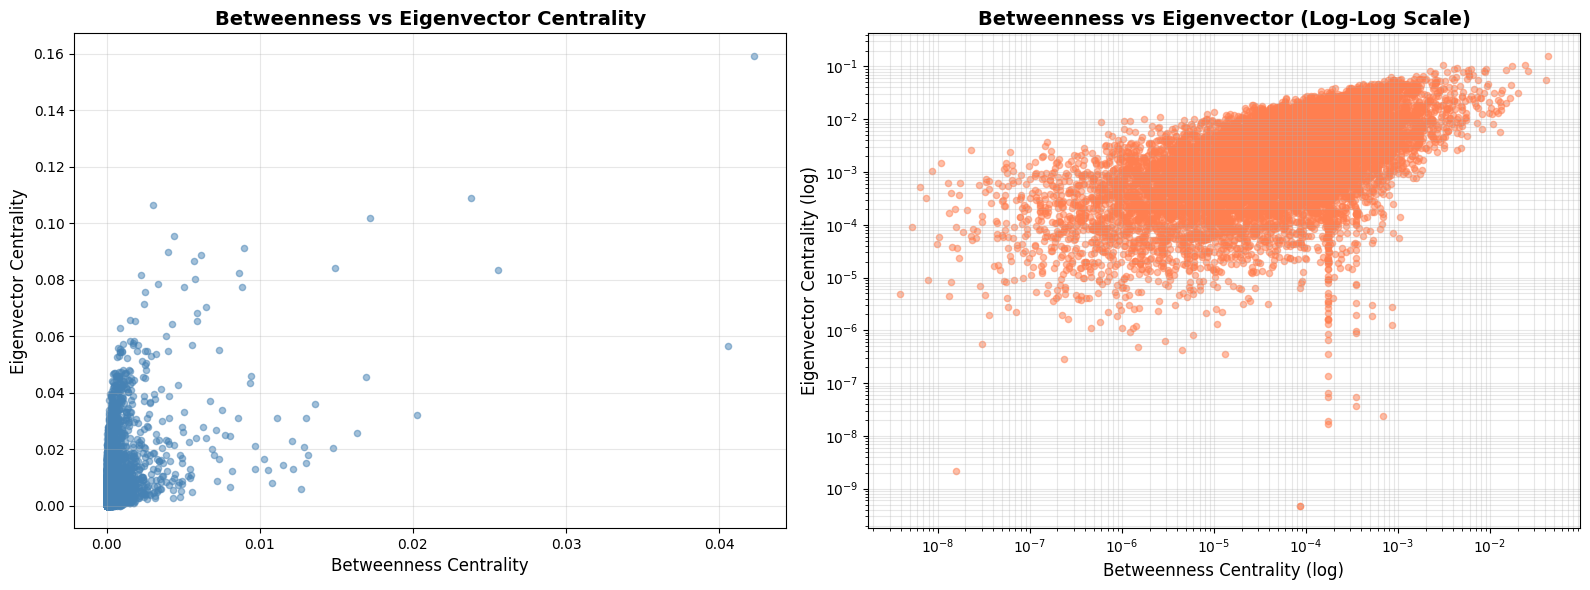

Correlation coefficient: 0.4748
P-value: 0.0000e+00
Non-zero values: 10389 out of 11286 nodes


In [10]:
# Compare betweenness and eigenvector centrality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

nodes_list = list(network.nodes())
bc_array = np.array([betweenness.get(n, 0) for n in nodes_list])
ec_array = np.array([eigenvector.get(n, 0) for n in nodes_list])

# Left: Regular scale
ax1.scatter(bc_array, ec_array, alpha=0.5, s=20, color='steelblue')
ax1.set_title("Betweenness vs Eigenvector Centrality", fontsize=14, fontweight='bold')
ax1.set_xlabel("Betweenness Centrality", fontsize=12)
ax1.set_ylabel("Eigenvector Centrality", fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: Log-log scale to see the spread better
# Filter out zeros for log scale
mask = (bc_array > 0) & (ec_array > 0)
bc_nonzero = bc_array[mask]
ec_nonzero = ec_array[mask]

ax2.scatter(bc_nonzero, ec_nonzero, alpha=0.5, s=20, color='coral')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Betweenness vs Eigenvector (Log-Log Scale)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Betweenness Centrality (log)", fontsize=12)
ax2.set_ylabel("Eigenvector Centrality (log)", fontsize=12)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Calculate correlation
from scipy import stats
if len(bc_nonzero) > 0:
    corr, p_value = stats.pearsonr(bc_nonzero, ec_nonzero)
    print(f"Correlation coefficient: {corr:.4f}")
    print(f"P-value: {p_value:.4e}")
    print(f"Non-zero values: {len(bc_nonzero)} out of {len(bc_array)} nodes")

## Power-Law Analysis of Degree Distributions

In [11]:
import powerlaw

# Calculate power-law exponents for in-degree, out-degree, and total degree
in_degree_fit = powerlaw.Fit(in_degrees[in_degrees > 0], xmin=1)
out_degree_fit = powerlaw.Fit(out_degrees[out_degrees > 0], xmin=1)
total_degree_fit = powerlaw.Fit(total_degrees[total_degrees > 0], xmin=1)

print(f"\nIn-Degree Power-Law Exponent (alpha): {in_degree_fit.alpha:.3f}")
print(f"Out-Degree Power-Law Exponent (alpha): {out_degree_fit.alpha:.3f}")
print(f"Total Degree Power-Law Exponent (alpha): {total_degree_fit.alpha:.3f}")


In-Degree Power-Law Exponent (alpha): 1.527
Out-Degree Power-Law Exponent (alpha): 1.497
Total Degree Power-Law Exponent (alpha): 1.384


Power law exponent of $<2$ means that the network is an ultra small network.

## Correlation: Page Length vs Degree

In [12]:
# Add length_of_content attribute for each node
from pathlib import Path

for node in network.nodes():
    nameURL = network.nodes[node].get('NameURL', '')
    file_path = Path(f"wikipages/{nameURL}.txt")
    
    if file_path.exists():
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                network.nodes[node]['length_of_content'] = len(content)
        except:
            network.nodes[node]['length_of_content'] = 0
    else:
        network.nodes[node]['length_of_content'] = 0

print("✓ Added length_of_content attribute to all nodes")

✓ Added length_of_content attribute to all nodes


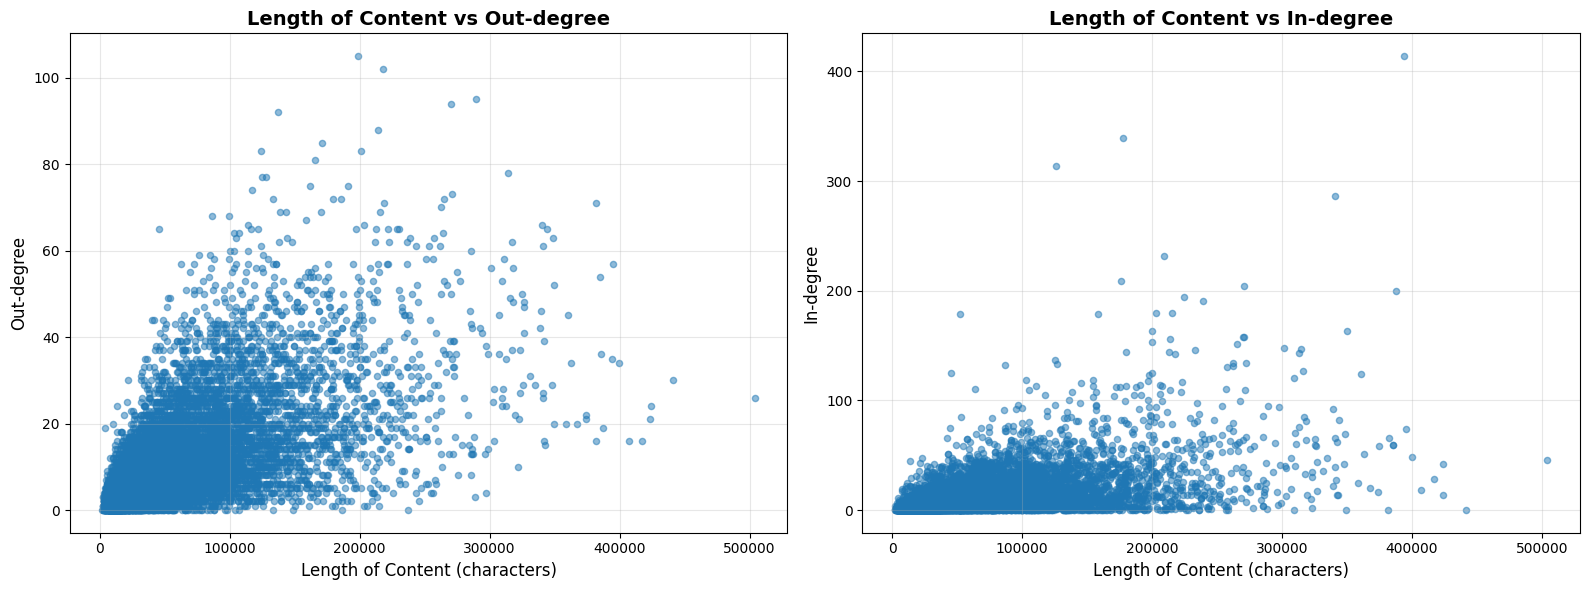

In [13]:
# Extract lengths for all nodes
lengths = np.array([network.nodes[node].get('length_of_content', 0) for node in network.nodes()])

# Filter out nodes with zero length
valid_mask = lengths > 0
lengths_filtered = lengths[valid_mask]
in_degrees_filtered = in_degrees[valid_mask]
out_degrees_filtered = out_degrees[valid_mask]

# Plot Length vs Out-degree and Length vs In-degree
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Length vs Out-degree
axes[0].scatter(lengths_filtered, out_degrees_filtered, alpha=0.5, s=20)
axes[0].set_xlabel("Length of Content (characters)", fontsize=12)
axes[0].set_ylabel("Out-degree", fontsize=12)
axes[0].set_title("Length of Content vs Out-degree", fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Length vs In-degree
axes[1].scatter(lengths_filtered, in_degrees_filtered, alpha=0.5, s=20)
axes[1].set_xlabel("Length of Content (characters)", fontsize=12)
axes[1].set_ylabel("In-degree", fontsize=12)
axes[1].set_title("Length of Content vs In-degree", fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As expected, the lengthier the page content is the out degree the node will have. The same can not be said for in degree as there is no correclation between a celebrity's page length to popularity.